# Supplementary Figure — SBS3 burden vs WGD and TP53 status

Per-sample SBS3 mutational burden (genome-size-normalised, per Mb) in HRDetect-positive
breast cancers (PCAWG, SCAN-B, INFORM), compared between:

* **a.** non-WGD vs WGD tumours
* **b.** TP53-wildtype vs TP53-mutant tumours

The notebook is fully self-contained: SBS3 burden is read from Sup. Table 13
(`SBS3 burden` sheet), and WGD / TP53 status are read from Sup. Table 1
(`Metadata` sheet).

| Panel | Source table |
|-------|--------------|
| a. nonWGD vs WGD | Sup. Table 13, sheet `SBS3 burden` (`is_WGD`) |
| b. TP53 WT vs mutant | Sup. Table 13 merged with Sup. Table 1, sheet `Metadata` (`TP53_mutated`) |


In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
})

TABLES = Path("../supplemental_tables_v2")
OUT    = Path("../output/SuppFig_SBS3_burden_WGD_TP53"); OUT.mkdir(parents=True, exist_ok=True)

T13 = TABLES / "SupTable17_SBS3_burden_WGD_TP53.xlsx"
T1  = TABLES / "SupTable1_WGS_metadata.xlsx"

In [2]:
# --- Load SBS3 burden (Sup. Table 13) and merge TP53 status (Sup. Table 1) ---
sbs3 = pd.read_excel(T13, sheet_name="SBS3 burden")
meta = pd.read_excel(T1, sheet_name="Metadata")[["sample_id", "TP53_mutated"]]

df = sbs3.merge(meta, on="sample_id", how="left")
n_missing_tp53 = df["TP53_mutated"].isna().sum()

print(f"Samples: {len(df)}")
print(df.groupby("is_WGD").size().rename("n"))
print(df.groupby("TP53_mutated").size().rename("n"))
if n_missing_tp53:
    print(f"(dropped from TP53 panel: n={n_missing_tp53} with missing TP53_mutated)")

Samples: 130
is_WGD
False    39
True     91
Name: n, dtype: int64
TP53_mutated
False     26
True     104
Name: n, dtype: int64


In [3]:
def sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


def boxplot_panel(ax, series_a, series_b, label_a, label_b, ylabel):
    plot_df = pd.concat([
        pd.DataFrame({"value": series_a, "group": label_a}),
        pd.DataFrame({"value": series_b, "group": label_b}),
    ]).reset_index(drop=True)

    lw = 0.25
    sns.boxplot(data=plot_df, x="group", y="value", order=[label_a, label_b],
                width=0.5, fliersize=0, linewidth=lw, color="lightgrey",
                boxprops=dict(edgecolor="black", linewidth=lw),
                whiskerprops=dict(color="black", linewidth=lw),
                capprops=dict(color="black", linewidth=lw),
                medianprops=dict(color="black", linewidth=lw), ax=ax)
    sns.stripplot(data=plot_df, x="group", y="value", order=[label_a, label_b],
                  color="black", size=2, jitter=0.15, zorder=4, ax=ax)

    for i, (lbl, s) in enumerate([(label_a, series_a), (label_b, series_b)]):
        ax.text(i, s.max() * 1.02, f"n={len(s)}", ha="center", va="bottom", fontsize=8)

    _, p_val = mannwhitneyu(series_a, series_b, alternative="two-sided")
    y_max = plot_df["value"].max()
    bracket_y = y_max * 1.10
    tick_h = y_max * 0.02
    ax.plot([0, 0, 1, 1],
            [bracket_y - tick_h, bracket_y, bracket_y, bracket_y - tick_h],
            color="black", linewidth=lw)
    ax.text(0.5, bracket_y + tick_h * 0.5, sig_stars(p_val),
            ha="center", va="bottom", fontsize=9)

    for spine in ax.spines.values():
        spine.set_linewidth(lw)
    ax.tick_params(width=lw)

    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(top=y_max * 1.30)
    return p_val

## a-b. SBS3 exposure per Mb — nonWGD vs WGD, TP53 WT vs mutant

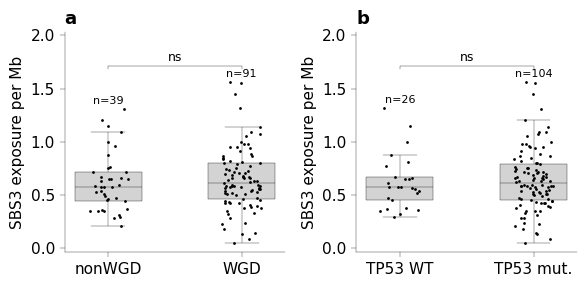

In [4]:
sbs3_nonwgd = df.loc[~df["is_WGD"], "SBS3_exposure_per_Mb"]
sbs3_wgd    = df.loc[df["is_WGD"],  "SBS3_exposure_per_Mb"]

tp53_df      = df.dropna(subset=["TP53_mutated"])
sbs3_tp53wt  = tp53_df.loc[~tp53_df["TP53_mutated"], "SBS3_exposure_per_Mb"]
sbs3_tp53mut = tp53_df.loc[tp53_df["TP53_mutated"],  "SBS3_exposure_per_Mb"]

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
boxplot_panel(axes[0], sbs3_nonwgd, sbs3_wgd,     "nonWGD",  "WGD",     "SBS3 exposure per Mb")
boxplot_panel(axes[1], sbs3_tp53wt, sbs3_tp53mut, "TP53 WT", "TP53 mut.", "SBS3 exposure per Mb")
axes[0].set_title("a", loc="left", fontweight="bold", fontsize=13)
axes[1].set_title("b", loc="left", fontweight="bold", fontsize=13)

plt.tight_layout()
fig.savefig(OUT / "SuppFig_SBS3_burden_WGD_TP53.pdf", bbox_inches="tight")
plt.show()